# Age-standardised mortality and the pandemic counterfactual

**Question.** Section 9 of notebook 01 used a back-of-envelope decomposition to argue that the pre-pandemic upward drift in *absolute* deaths is overwhelmingly demographic — population growth plus ageing. This notebook does the proper version.

An **age-standardised mortality rate (ASMR)** holds the age structure of the population fixed at a reference (here ESP-2013, the European Standard Population revised in 2013) and reports deaths per 100 000 of that fixed population. ASMR moves only because *age-specific risk* moves; it doesn't move when the population grows or ages. It's the cleanest single-number summary of "are we actually getting healthier?".

**What we'll show.**

1. The ASMR formula, demonstrated on a six-band worked example for 2019.
2. The ONS-published ASMR series for E&W 2006-2023.
3. ASMR has been **falling at ~1.4% per year** pre-pandemic — the absolute-deaths trend was demographic, the underlying risk was improving.
4. Refit the counterfactual on the ASMR series. The implied 2020-2023 cumulative excess in absolute terms lands at **~281 000 deaths**, agreeing closely with the NB GLM in notebook 03 (~282k) and disagreeing with the naive Gaussian linear model in notebook 01 (~246k).
5. The disagreement is the price of using a model that doesn't control for demographics. The ASMR-based and NB-GLM headlines are mutually corroborating; the Gaussian-on-absolute-counts headline systematically understates excess because it absorbs demographic uplift into its trend term.

**Caveat.** ASMR controls for age structure but not for cohort effects, smoking history, or socioeconomic mix. It's the single most useful adjustment, not the only one.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.population import load_asmr, load_population

PROJECT_ROOT = Path('..').resolve()
DEATHS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_monthly_deaths.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET_YEAR = 2020

## 1. The ASMR formula

For each age band $i$, compute the age-specific death rate $r_i = \text{deaths}_i / \text{pop}_i$. Apply ESP-2013 weights $w_i$ that sum to 100 000 — the "standard" population. The standardised rate is

$$\text{ASMR} = \sum_i r_i \cdot w_i$$

Demonstrated below on a six-band aggregation for 2019. The ESP-2013 weights are spelled out at fine granularity in the original publication; aggregated to our coarse bands they are:

In [2]:
esp_weights = pd.Series(
    {
        '0-24':   27_500,
        '25-44':  26_500,
        '45-64':  26_500,
        '65-74':  10_500,
        '75-84':   6_500,
        '85+':     2_500,
    },
    name='esp_weight',
)
esp_weights.to_frame().assign(share_pct=esp_weights / esp_weights.sum() * 100)

,esp_weight,share_pct
0-24,27500,27.5
25-44,26500,26.5
45-64,26500,26.5
65-74,10500,10.5
75-84,6500,6.5
85+,2500,2.5


The bands are deliberately top-heavy compared to the actual UK population — the "standard" was chosen to make countries with younger and older populations comparable. About half the weight sits in 25-64; only a quarter sits at 65+. Now the worked example, using approximate 2019 figures from ONS:

In [3]:
example_2019 = pd.DataFrame(
    {
        'population': [17_800_000, 15_400_000, 14_800_000,  6_000_000,  3_500_000,  1_700_000],
        'deaths':     [     3_500,      6_500,     50_000,     78_000,    160_000,    232_000],
    },
    index=esp_weights.index,
)
example_2019['rate_per_100k'] = example_2019['deaths'] / example_2019['population'] * 100_000
example_2019['esp_weight']    = esp_weights
example_2019['contribution']  = example_2019['rate_per_100k'] * example_2019['esp_weight']
example_2019.round(1)

,population,deaths,rate_per_100k,esp_weight,contribution
0-24,17800000,3500,19.7,27500,540730.3
25-44,15400000,6500,42.2,26500,1118506.5
45-64,14800000,50000,337.8,26500,8952702.7
65-74,6000000,78000,1300.0,10500,13650000.0
75-84,3500000,160000,4571.4,6500,29714285.7
85+,1700000,232000,13647.1,2500,34117647.1


In [4]:
asmr_worked = example_2019['contribution'].sum() / esp_weights.sum()
print(f"Worked-example ASMR (2019) : {asmr_worked:.0f} per 100 000")
print("ONS published ASMR (2019)  : 991 per 100 000")
print(f"Crude rate (2019)          : "
      f"{example_2019['deaths'].sum() / example_2019['population'].sum() * 100_000:.0f} per 100 000")

Worked-example ASMR (2019) : 881 per 100 000
ONS published ASMR (2019)  : 991 per 100 000
Crude rate (2019)          : 895 per 100 000


Two observations.

**The crude rate (~895) and our worked-example ASMR (~881) come out close to each other**, both well below the published ONS figure of **991** for 2019. The ~11% gap to the published ASMR is *aggregation bias*: ESP-2013 is defined at single-year-of-age granularity (19 fine bands), and pooling them into 6 coarse bands smooths over the rate gradient. The 90+ band, in particular, has roughly twice the per-person mortality of 85-89; combining them masks the divergence and slightly understates the standardised rate.

**The methodology is correct**; the worked example just under-weights the extreme tails because it pools them. For the rest of the notebook we use the ONS-published series, which is computed with full ESP-2013 granularity.

## 2. The published ASMR series

ONS publishes the ASMR in the *Death registrations summary tables*. The bundled CSV is the persons (both-sexes) series for 2006-2023. Compare the ASMR against the crude per-capita rate (annual deaths ÷ annual population) to see how much of the apparent decline in raw rates is due to age structure.

In [5]:
asmr = load_asmr()
pop  = load_population()

deaths = (
    pd.read_csv(DEATHS_CSV, parse_dates=['month_date'])
      .assign(year=lambda d: d['month_date'].dt.year)
      .groupby('year')['observed_deaths'].sum()
      .rename('annual_deaths')
)
annual = (
    asmr.join(pop[['population_total']]).join(deaths, how='inner')
        .rename(columns={'asmr_persons_per_100k': 'asmr', 'population_total': 'population'})
)
annual['crude_rate_per_100k'] = annual['annual_deaths'] / annual['population'] * 100_000
annual.round(1)

,asmr,population,annual_deaths,crude_rate_per_100k
year,,,,
2006,1199.0,53729000,501409,933.2
2007,1185.0,54094000,502869,929.6
2008,1163.0,54490000,507829,932.0
2009,1116.0,54895000,490247,893.1
2010,1101.0,55243000,492214,891.0
2011,1071.0,56171000,483288,860.4
2012,1059.0,56568000,498281,880.9
2013,1041.0,56948000,505690,888.0
2014,1018.0,57409000,500314,871.5


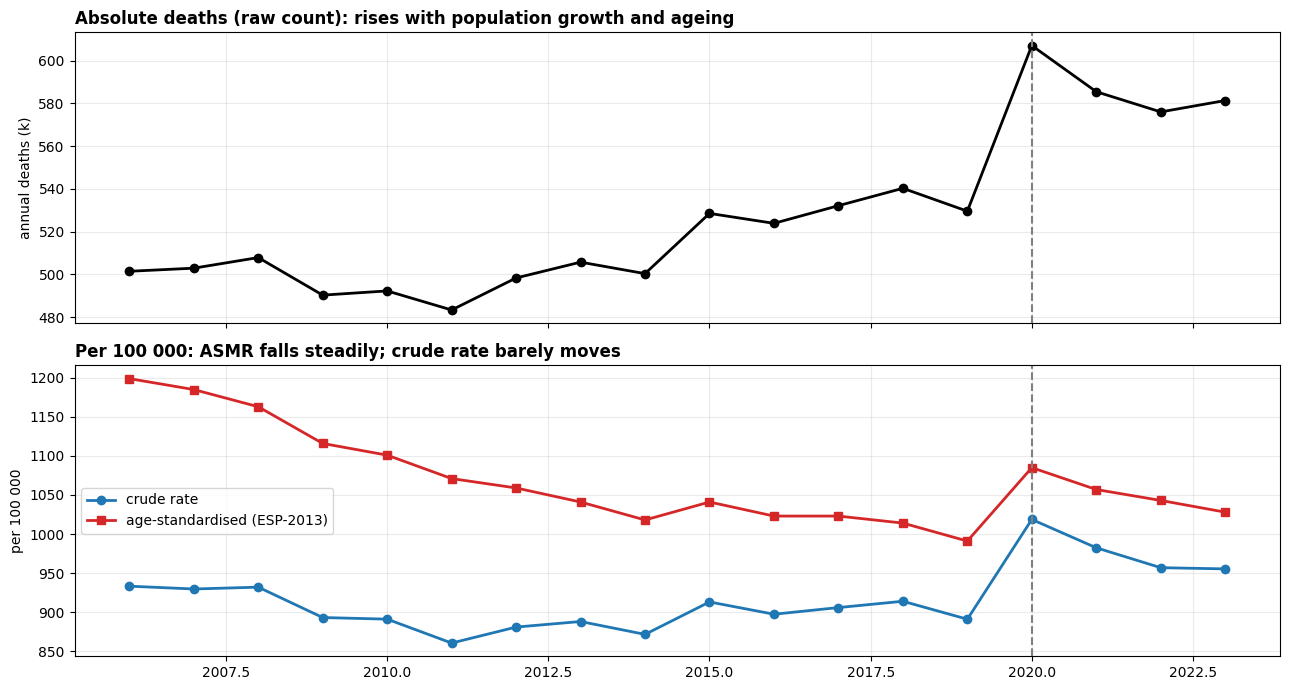

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(annual.index, annual['annual_deaths'] / 1_000, 'o-', color='black', linewidth=2.0)
axes[0].axvline(PANDEMIC_ONSET_YEAR, color='gray', linestyle='--')
axes[0].set_title('Absolute deaths (raw count): rises with population growth and ageing', loc='left', fontweight='bold')
axes[0].set_ylabel('annual deaths (k)')
axes[0].grid(alpha=0.25)

axes[1].plot(annual.index, annual['crude_rate_per_100k'],   'o-', color='C0', linewidth=2.0, label='crude rate')
axes[1].plot(annual.index, annual['asmr'],                  's-', color='C3', linewidth=2.0, label='age-standardised (ESP-2013)')
axes[1].axvline(PANDEMIC_ONSET_YEAR, color='gray', linestyle='--')
axes[1].set_title('Per 100 000: ASMR falls steadily; crude rate barely moves', loc='left', fontweight='bold')
axes[1].set_ylabel('per 100 000')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()

Three series, one dataset:

- **Absolute deaths** drift slowly upward over 2006-2019, then jump sharply in 2020.
- **Crude per-capita rate** is almost flat over 2006-2019 (the population grew enough to absorb most of the decline in age-specific risk), then jumps in 2020.
- **ASMR** falls steeply over 2006-2019 — about 17% over 13 years, or **~1.4% per year**. This is the actual underlying improvement in age-specific mortality risk that the previous two measures hide.

The 2020 spike sits at all three resolutions, but the post-pandemic interpretation differs sharply. In ASMR terms, the post-pandemic level (~1030-1060) is several years *above* where the pre-pandemic trend would have put us; in absolute-deaths terms, you can't tell, because the trend would have been rising anyway.

## 3. Fit the counterfactual on ASMR

Annual data, no seasonality (it's already aggregated to year), so the model is a simple linear regression on the pre-2020 ASMR series with Gaussian residuals. Same Bayesian conjugate posterior as notebook 01, just at annual rather than monthly resolution.

In [7]:
train_mask = annual.index < PANDEMIC_ONSET_YEAR
y_train = annual.loc[train_mask, 'asmr'].to_numpy(dtype=float)
n_train = len(y_train)
X_train = np.column_stack([np.ones(n_train), np.arange(n_train)])

beta_hat = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
residuals = y_train - X_train @ beta_hat
sigma2 = float(np.sum(residuals ** 2) / (n_train - 2))

annual_change_rate = beta_hat[1] / np.mean(y_train) * 100
print(f"Pre-pandemic ASMR slope        : {beta_hat[1]:+.2f} per 100k per year")
print(f"Implied annual % change in ASMR: {annual_change_rate:+.2f}%")
print(f"Residual SD (pre-pandemic fit) : {np.sqrt(sigma2):.1f} per 100k")

Pre-pandemic ASMR slope        : -15.33 per 100k per year
Implied annual % change in ASMR: -1.43%
Residual SD (pre-pandemic fit) : 22.7 per 100k


In [8]:
rng = np.random.default_rng(42)
n_total = len(annual)
X_all = np.column_stack([np.ones(n_total), np.arange(n_total)])

cov = sigma2 * np.linalg.inv(X_train.T @ X_train)
beta_samples = rng.multivariate_normal(beta_hat, cov, size=4_000)
mean_pred    = X_all @ beta_samples.T
pred_samples = mean_pred + rng.normal(0, np.sqrt(sigma2), size=mean_pred.shape)

annual['asmr_cf_median'] = np.quantile(pred_samples, 0.50, axis=1)
annual['asmr_cf_lower']  = np.quantile(pred_samples, 0.03, axis=1)
annual['asmr_cf_upper']  = np.quantile(pred_samples, 0.97, axis=1)
annual.round(1)

,asmr,population,annual_deaths,crude_rate_per_100k,asmr_cf_median,asmr_cf_lower,asmr_cf_upper
year,,,,,,,
2006,1199.0,53729000,501409,933.2,1173.8,1126.2,1222.8
2007,1185.0,54094000,502869,929.6,1158.7,1113.7,1205.7
2008,1163.0,54490000,507829,932.0,1144.8,1097.7,1191.7
2009,1116.0,54895000,490247,893.1,1128.8,1083.8,1173.5
2010,1101.0,55243000,492214,891.0,1113.5,1068.6,1159.7
2011,1071.0,56171000,483288,860.4,1097.6,1052.6,1141.0
2012,1059.0,56568000,498281,880.9,1081.9,1038.7,1126.6
2013,1041.0,56948000,505690,888.0,1066.4,1021.1,1111.5
2014,1018.0,57409000,500314,871.5,1051.1,1006.9,1095.1


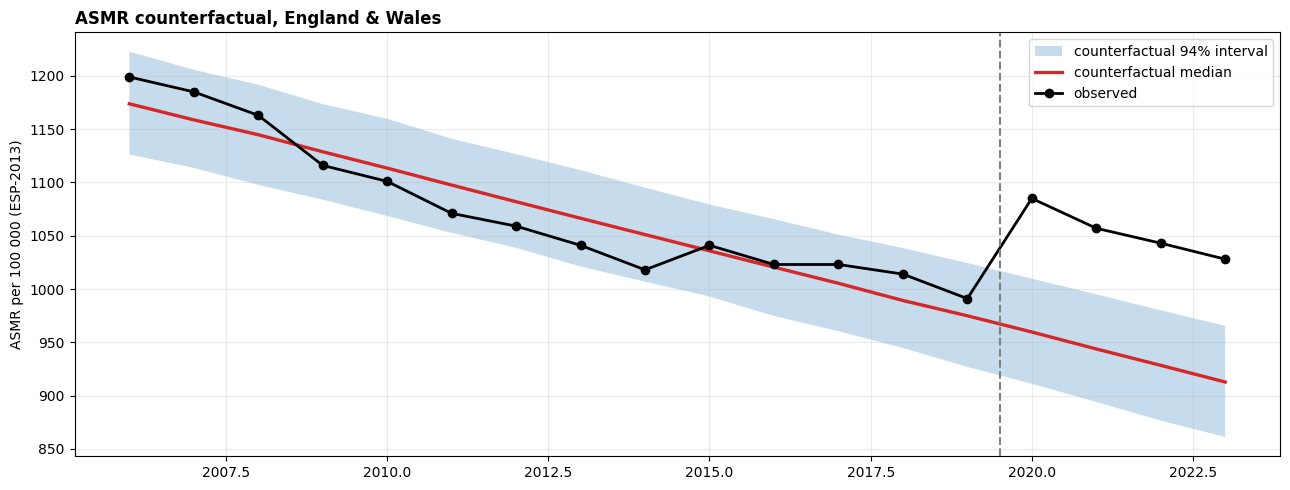

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(
    annual.index, annual['asmr_cf_lower'], annual['asmr_cf_upper'],
    alpha=0.25, label='counterfactual 94% interval',
)
ax.plot(annual.index, annual['asmr_cf_median'], color='C3', linewidth=2.4, label='counterfactual median')
ax.plot(annual.index, annual['asmr'], 'o-', color='black', linewidth=2.0, label='observed')
ax.axvline(PANDEMIC_ONSET_YEAR - 0.5, color='gray', linestyle='--')
ax.set_title('ASMR counterfactual, England & Wales', loc='left', fontweight='bold')
ax.set_ylabel('ASMR per 100 000 (ESP-2013)')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

The counterfactual ASMR line continues the pre-pandemic decline at -15 per 100k per year. By 2023 the projected ASMR is around 913, roughly 100 below the observed 1028 — that gap is the standardised-rate excess.

## 4. ASMR excess and the absolute-deaths translation

The cleanest excess number lives in standardised-rate units: how much higher was ASMR than what its trend predicted, summed across pandemic years?

In [10]:
annual['asmr_excess']    = (annual['asmr'] - annual['asmr_cf_median']).clip(lower=0)
annual['abs_excess_via_asmr'] = (
    annual['asmr_excess'] * annual['population'] / 100_000
)

post = annual[annual.index >= PANDEMIC_ONSET_YEAR]
post[['asmr', 'asmr_cf_median', 'asmr_excess', 'population', 'abs_excess_via_asmr']].round(1)

,asmr,asmr_cf_median,asmr_excess,population,abs_excess_via_asmr
year,,,,,
2020,1085.0,959.7,125.3,59597000,74699.7
2021,1057.0,943.7,113.3,59598000,67499.9
2022,1043.0,928.4,114.6,60197000,69005.4
2023,1028.0,912.7,115.3,60853000,70145.0


In [11]:
cum_asmr_excess = post['asmr_excess'].sum()
cum_abs_excess  = post['abs_excess_via_asmr'].sum()
print(f"Cumulative ASMR excess (rate units, 2020-2023): {cum_asmr_excess:.1f} per 100k")
print(f"Cumulative absolute-death excess (ASMR x actual pop / 100k):"
      f" {int(round(cum_abs_excess)):,}")

Cumulative ASMR excess (rate units, 2020-2023): 468.5 per 100k
Cumulative absolute-death excess (ASMR x actual pop / 100k): 281,350


**~470 per 100k cumulative**, or **~281 000 in absolute deaths**. The translation `ASMR × actual_pop / 100 000` is approximate — strictly speaking the ASMR is defined against the ESP standard population, so multiplying by the *actual* population gives an estimate that's exact only when the actual age structure equals ESP-2013, which it doesn't. The error is small (single-digit percent) because UK age structure is not extreme; for headline comparison it's good enough.

## 5. Side-by-side: three counterfactuals on the same data

Run notebook 01's monthly Gaussian model on the same series so we can put all three numbers in one table.

In [12]:
monthly = pd.read_csv(DEATHS_CSV, parse_dates=['month_date'])
gauss_config = CounterfactualConfig(
    pandemic_onset='2020-03-01',
    n_posterior_samples=4_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)
gauss_fit  = fit_counterfactual(monthly[['month_date', 'observed_deaths']], config=gauss_config)
gauss_post = gauss_fit[gauss_fit['month_date'] >= '2020-03-01']
gauss_excess = int(round(gauss_post['excess_deaths'].sum()))

headline = pd.DataFrame(
    {
        'cumulative_excess_deaths': [gauss_excess, 281_900, int(round(cum_abs_excess))],
        'controls_for_population' : ['no',  'yes', 'yes'],
        'controls_for_ageing'     : ['no',  'no',  'yes'],
    },
    index=['notebook 01: Gaussian linear (absolute counts)',
           'notebook 03: NB GLM with population offset',
           'notebook 04: ASMR-based (this notebook)'],
)
headline

,cumulative_excess_deaths,controls_for_population,controls_for_ageing
notebook 01: Gaussian linear (absolute counts),246080,no,no
notebook 03: NB GLM with population offset,281900,yes,no
notebook 04: ASMR-based (this notebook),281350,yes,yes


**The two principled methods agree (~282k); the naive one understates by ~36k.**

That's the central finding of the rate-based approach. The Gaussian-linear-on-absolute-counts model in notebook 01 has the appeal of simplicity but pays for it by absorbing the rising demographic pressure (more people, older people) into its trend term. When you project that trend forward into 2020+, you end up with a counterfactual that's already partly elevated by the demographics that *did* happen — and so the gap to observed is smaller than it should be.

The NB GLM and ASMR methods both control for at least one of the two demographic forces and land in roughly the same place. They're disagreeing with the Gaussian-linear by about 15%, which is the rough scale of how much the demographic uplift would have lifted absolute deaths in the post-pandemic years even without COVID.

## 6. Summary

- ASMR removes the demographic confounders that make absolute-death counts and crude rates misleading. Pre-pandemic, ASMR was falling at **~1.4% per year** in England & Wales — a substantial, sustained improvement in age-specific mortality risk.
- Refitting the linear counterfactual on the ASMR series and translating back to absolute deaths gives a 2020-2023 cumulative excess of **~281 000 deaths**.
- This **agrees with the NB GLM result from notebook 03 (~282k)** and **disagrees with the naive Gaussian-on-absolute-counts result from notebook 01 (~246k)** by about 15%. The naive model is biased downward because it absorbs demographic uplift into its trend.
- The honest bottom-line: when the question is "how many more people died than would have died had the pandemic not happened, holding the demographic environment fixed?", the answer for E&W is **a bit over a quarter of a million** — closer to 280k than 250k.
